библиотеки

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay

подгрузка датасета

In [3]:
ds = pd.read_csv('iris.csv')
ds

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower_name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


распределения признаков

<Axes: xlabel='sepal length (cm)', ylabel='Count'>

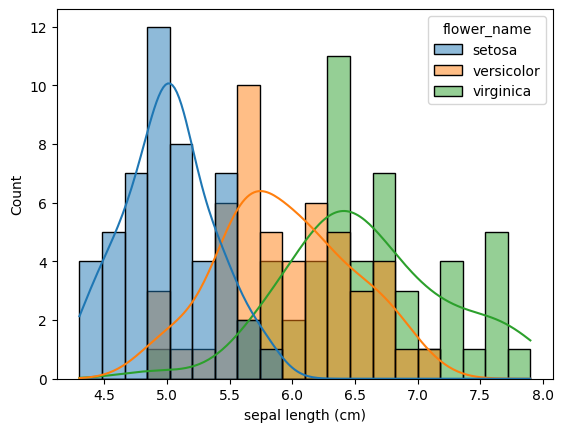

In [4]:
sns.histplot(data=ds, x='sepal length (cm)', hue='flower_name', bins=20, kde=True)

<Axes: xlabel='sepal width (cm)', ylabel='Count'>

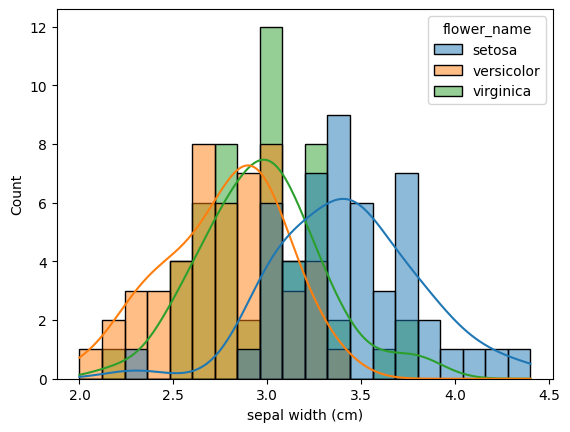

In [5]:
sns.histplot(data=ds, x='sepal width (cm)', hue='flower_name', bins=20, kde=True)

<Axes: xlabel='petal length (cm)', ylabel='Count'>

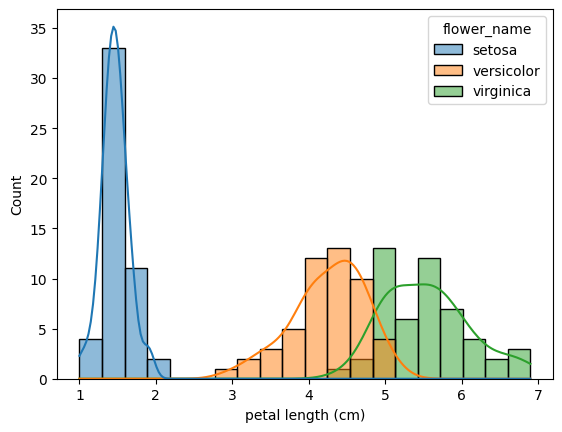

In [6]:
sns.histplot(data=ds, x='petal length (cm)', hue='flower_name', bins=20, kde=True)

<Axes: xlabel='petal width (cm)', ylabel='Count'>

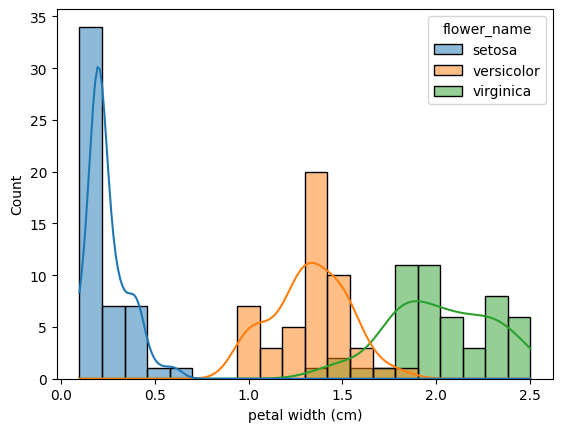

In [7]:
sns.histplot(data=ds, x='petal width (cm)', hue='flower_name', bins=20, kde=True)

выбросы

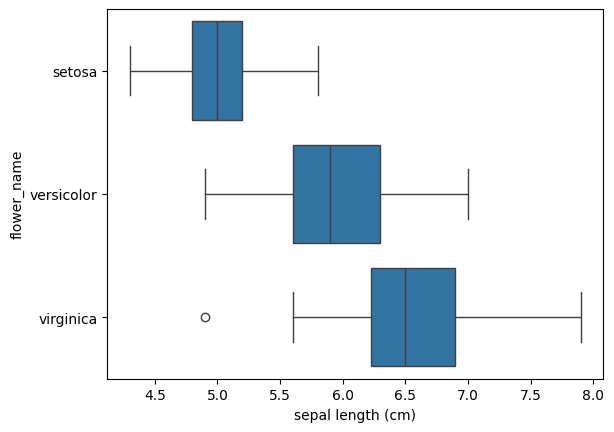

In [8]:
sns.boxplot(x='sepal length (cm)', y='flower_name', data=ds)
plt.show()


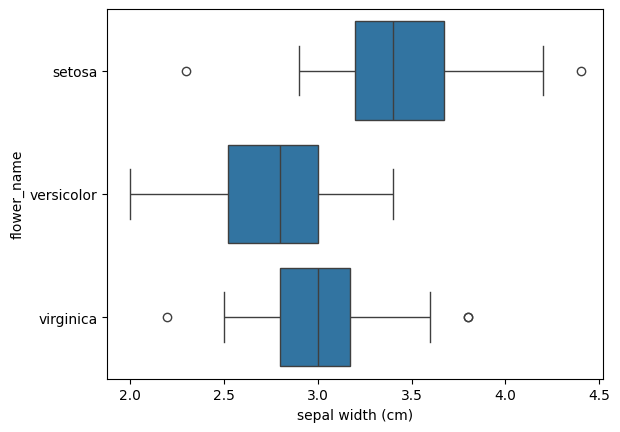

In [9]:
sns.boxplot(x='sepal width (cm)', y='flower_name', data=ds)
plt.show()


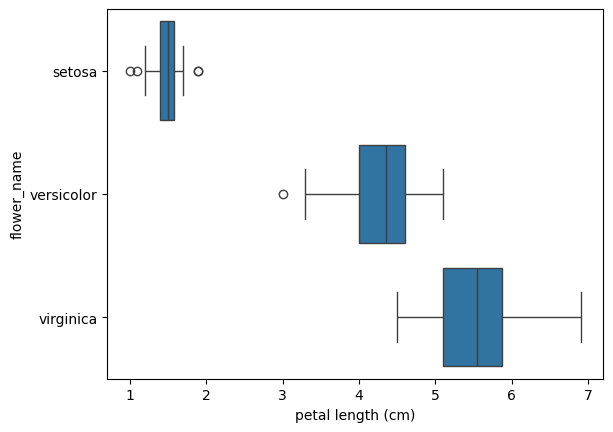

In [10]:
sns.boxplot(x='petal length (cm)', y='flower_name', data=ds)
plt.show()


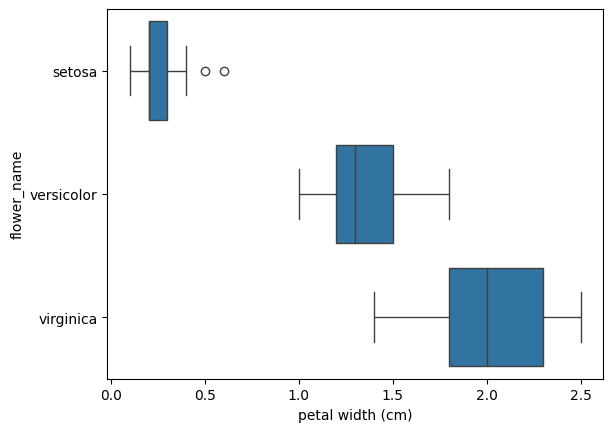

In [11]:
sns.boxplot(x='petal width (cm)', y='flower_name', data=ds)
plt.show()


избавление от выбросов

In [12]:
def remove_outliers_by_group(df, cols, group_col):
    result = []
    for group in df[group_col].unique():
        subset = df[df[group_col] == group].copy()
        for c in cols:
            Q1 = subset[c].quantile(0.25)
            Q3 = subset[c].quantile(0.75)
            IQR = Q3 - Q1
            subset = subset[subset[c].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)]
        result.append(subset)
    return pd.concat(result).reset_index(drop=True)

cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
ds_clean = remove_outliers_by_group(ds, cols, group_col='flower_name')


ds.shape[0], ds_clean.shape[0]

(150, 143)

разделение на признаки

In [18]:
cat_map = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
ds['flower_code'] = ds['flower_name'].map(cat_map)
ds_clean['flower_code'] = ds_clean['flower_name'].map(cat_map)
x = ds[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']]
y = ds['flower_code']
x_clear = ds_clean[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].reset_index(drop=True)
y_clear = ds_clean['flower_code'].reset_index(drop=True)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
xc_train, xc_test, yc_train, yc_test = train_test_split(x_clear, y_clear, test_size=0.2, random_state=42)
ds.corr(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower_code
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
flower_code,0.782561,-0.426658,0.949035,0.956547,1.000000


In [19]:
ds_clean.corr(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower_code
sepal length (cm),1.000000,-0.140215,0.877629,0.825383,0.796541
sepal width (cm),-0.140215,1.000000,-0.433339,-0.364463,-0.421264
petal length (cm),0.877629,-0.433339,1.000000,0.962920,0.949210
petal width (cm),0.825383,-0.364463,0.962920,1.000000,0.956548
flower_code,0.796541,-0.421264,0.949210,0.956548,1.000000


In [20]:
model= LogisticRegression()
model.fit(xc_train, yc_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

метрики

In [21]:
y_pred = model.predict(x_test)
cr=classification_report(y_test, y_pred)

yc_pred = model.predict(xc_test)
cr_c=classification_report(yc_test, yc_pred)
print("с выбросами\n",cr)
print("без выбросов\n",cr_c)

с выбросами
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

без выбросов
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.82      0.90        11
           2       0.83      1.00      0.91        10

    accuracy                           0.93        29
   macro avg       0.94      0.94      0.94        29
weighted avg       0.94      0.93      0.93        29



график обучения

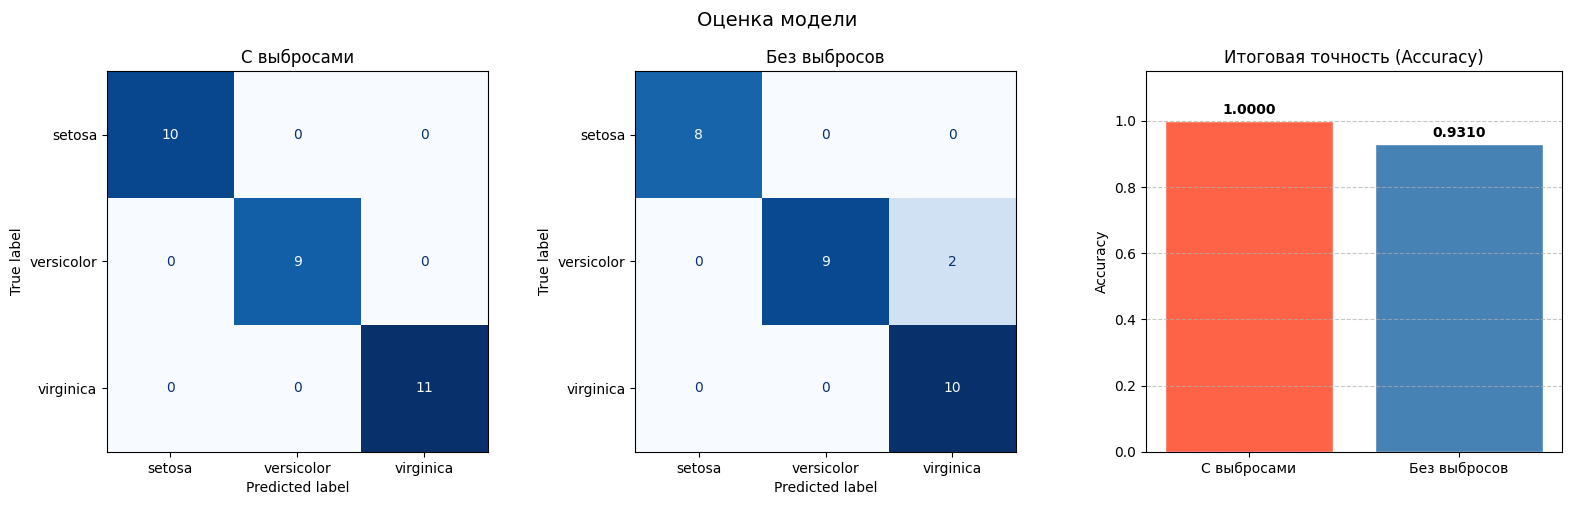

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cm1 = confusion_matrix(y_test, model.predict(x_test))
ConfusionMatrixDisplay(cm1, display_labels=['setosa', 'versicolor', 'virginica']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('С выбросами')
cm2 = confusion_matrix(yc_test, model.predict(xc_test))
ConfusionMatrixDisplay(cm2, display_labels=['setosa', 'versicolor', 'virginica']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Без выбросов')
names = ['С выбросами', 'Без выбросов']
acc_values = [
    accuracy_score(y_test, model.predict(x_test)),
    accuracy_score(yc_test, model.predict(xc_test))
]
bars = axes[2].bar(names, acc_values, color=['tomato', 'steelblue'], edgecolor='white')
axes[2].set_title('Итоговая точность (Accuracy)')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.15)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width() / 2, yval + 0.02,
                 f'{yval:.4f}', ha='center', fontweight='bold')

plt.suptitle('Оценка модели', fontsize=14)
plt.tight_layout()
plt.show()